# 🌳 Decision Tree Regression (DTR)

## What is Decision Tree Regression?

Decision Tree Regression predicts a numerical value by asking a series of yes/no questions and splitting the data into smaller groups until similar data points are together.

Decision Tree Regression is a Supervised Machine Learning Regression Algorithm used to predict continuous numerical values by repeatedly dividing the dataset into smaller groups based on decision rules.

Unlike Linear Regression, which tries to fit one straight line, Decision Tree Regression divides the data into many small regions and predicts the average value in each region.

## Import Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Read dataset

In [7]:
dataset = pd.read_csv(r"C:\Users\Lenovo\Downloads\student_placement_salary_elite_v2.csv")

In [8]:
dataset.head()

,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,company_type,job_role,salary_lpa
0,S0,6.87,Civil,1,1,1,0,0,15.6,4.3,92.0,1,3,0,62.6,2,1,MNC,Software Engineer,63.55
1,S1,6.52,Civil,2,1,0,0,1,13.9,5.8,62.0,1,6,0,77.5,2,1,MNC,Data Scientist,75.17
2,S2,5.33,IT,1,1,1,1,0,9.8,8.1,66.4,0,5,1,76.0,3,1,MNC,Software Engineer,80.44
3,S3,6.04,Civil,3,1,0,1,0,39.5,9.6,83.6,0,6,0,74.3,2,1,MNC,Software Engineer,72.11
4,S4,6.78,Mechanical,2,0,1,0,1,7.5,9.9,86.3,0,3,0,66.8,2,1,Mid-size,Software Engineer,67.05


In [9]:
dataset.info

<bound method DataFrame.info of      student_id  cgpa      branch  college_tier  python_skill  dsa_skill  \
0            S0  6.87       Civil             1             1          1   
1            S1  6.52       Civil             2             1          0   
2            S2  5.33          IT             1             1          1   
3            S3  6.04       Civil             3             1          0   
4            S4  6.78  Mechanical             2             0          1   
...         ...   ...         ...           ...           ...        ...   
8995      S8995  6.51          IT             2             1          0   
8996      S8996  7.74          IT             3             1          1   
8997      S8997  7.14         CSE             3             1          0   
8998      S8998  5.21          IT             1             1          0   
8999      S8999  6.05       Civil             2             1          1   

      ml_skill  web_dev_skill  coding_score  communicat

In [10]:
dataset.dtypes

student_id              object
cgpa                   float64
branch                  object
college_tier             int64
python_skill             int64
dsa_skill                int64
ml_skill                 int64
web_dev_skill            int64
coding_score           float64
communication_score    float64
aptitude_score         float64
internships              int64
projects                 int64
backlogs                 int64
resume_score           float64
skill_score              int64
placed                   int64
company_type            object
job_role                object
salary_lpa             float64
dtype: object

In [11]:
dataset.columns

Index(['student_id', 'cgpa', 'branch', 'college_tier', 'python_skill',
       'dsa_skill', 'ml_skill', 'web_dev_skill', 'coding_score',
       'communication_score', 'aptitude_score', 'internships', 'projects',
       'backlogs', 'resume_score', 'skill_score', 'placed', 'company_type',
       'job_role', 'salary_lpa'],
      dtype='object')

## Remove Student id

In [13]:
dataset = dataset.drop("student_id", axis=1) # are only IDs.They have no effect on salary prediction.

## Convert the text columns to numbers

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

dataset["branch"] = le.fit_transform(dataset["branch"])

dataset["company_type"] = le.fit_transform(dataset["company_type"])

dataset["job_role"] = le.fit_transform(dataset["job_role"])

In [16]:
print(dataset.head())  # let see here Everything should now be numeric.

   cgpa  branch  college_tier  python_skill  dsa_skill  ml_skill  \
0  6.87       1             1             1          1         0   
1  6.52       1             2             1          0         0   
2  5.33       4             1             1          1         1   
3  6.04       1             3             1          0         1   
4  6.78       5             2             0          1         0   

   web_dev_skill  coding_score  communication_score  aptitude_score  \
0              0          15.6                  4.3            92.0   
1              1          13.9                  5.8            62.0   
2              0           9.8                  8.1            66.4   
3              0          39.5                  9.6            83.6   
4              1           7.5                  9.9            86.3   

   internships  projects  backlogs  resume_score  skill_score  placed  \
0            1         3         0          62.6            2       1   
1            1    

## Seprate the X and Y

In [18]:
X = dataset.iloc[:,:1].values
y = dataset.iloc[:,1].values

## 3. Spilt Dataset

In [22]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=0)

## 4. Feature Scaling 

In [24]:
# Methode 1 : Single Feature Dataset

from sklearn.tree import DecisionTreeRegressor

dt_reg = DecisionTreeRegressor(
    criterion='squared_error',
    random_state=0
)

dt_reg.fit(X, y)

prediction = dt_reg.predict([[6.5]])

print(prediction)

[3.3]


## All Decision Tree Criteria

In [26]:
# 1. Squared error 

dt_reg = DecisionTreeRegressor(
    criterion='squared_error',
    random_state=0
)

dt_reg.fit(X, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [27]:
# 2. Friedman MSE

dt_reg = DecisionTreeRegressor(
    criterion='friedman_mse',
    random_state=0
)

dt_reg.fit(X, y)

,criterion,'friedman_mse'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [28]:
# 3. Absolute error 

dt_reg = DecisionTreeRegressor(
    criterion='absolute_error',
    random_state=0
)

dt_reg.fit(X, y)

,criterion,'absolute_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [29]:
# 4. Poisson

dt_reg = DecisionTreeRegressor(
    criterion='poisson',
    random_state=0
)

dt_reg.fit(X, y)

,criterion,'poisson'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## Hyperparameter

In [30]:
# Example 1:

dt_reg = DecisionTreeRegressor(

criterion='squared_error',

splitter='best',

max_depth=5,

min_samples_split=2,

min_samples_leaf=1,

max_features=None,

random_state=0
)

dt_reg.fit(X,y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [31]:
# Example 2:

dt_reg = DecisionTreeRegressor(

criterion='friedman_mse',

splitter='random',

max_depth=10,

min_samples_split=5,

min_samples_leaf=2,

max_features='sqrt',

random_state=0
)

dt_reg.fit(X,y)

,criterion,'friedman_mse'
,splitter,'random'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [32]:
# Example 3 

dt_reg = DecisionTreeRegressor(

criterion='absolute_error',

max_depth=8,

max_leaf_nodes=20,

random_state=0
)

dt_reg.fit(X,y)

,criterion,'absolute_error'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,20
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [33]:
# Example 4:

dt_reg = DecisionTreeRegressor(

criterion='poisson',

max_depth=6,

min_samples_leaf=3,

random_state=0
)

dt_reg.fit(X,y)

,criterion,'poisson'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## Decision Tree Plot

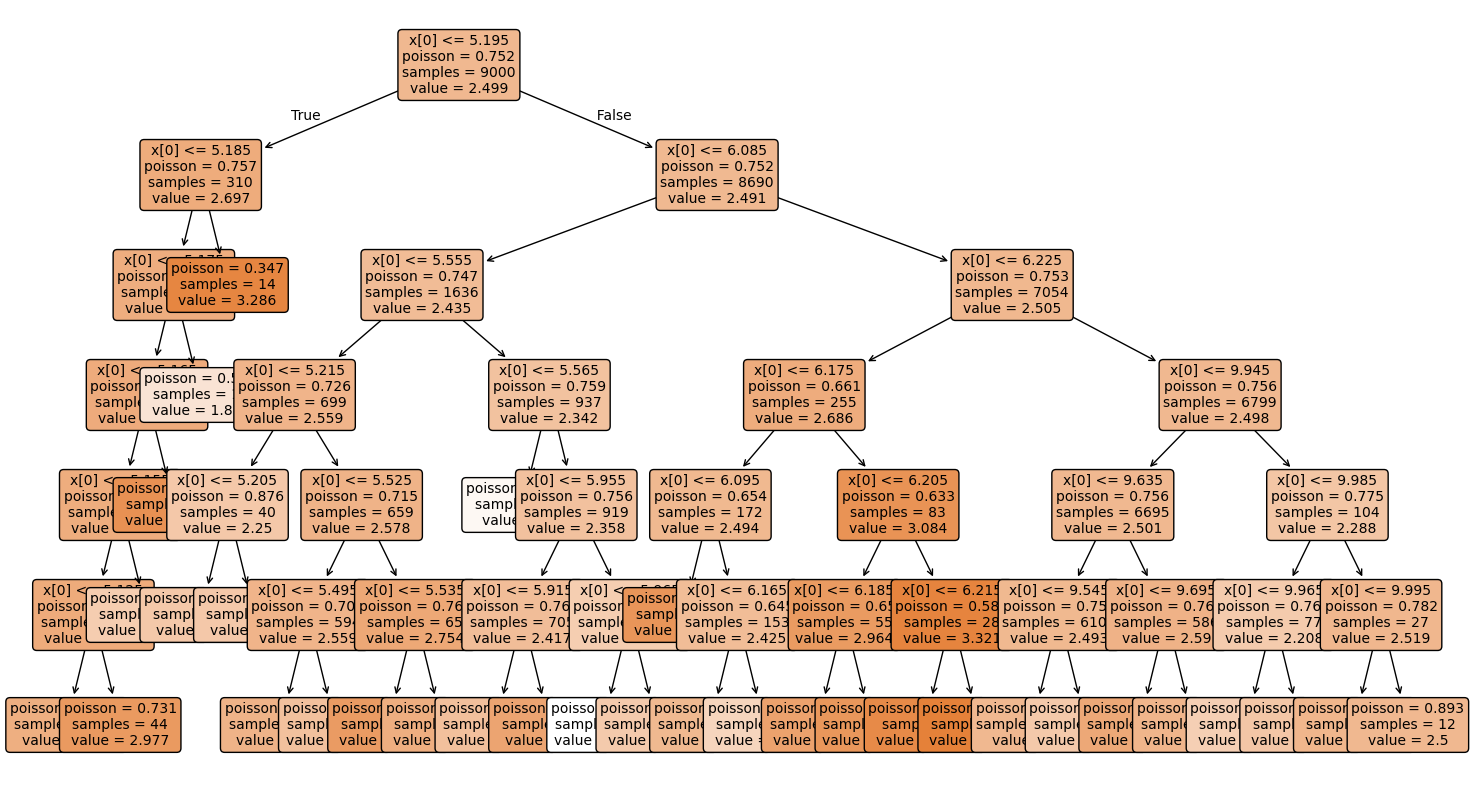

In [40]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))

plot_tree(
    dt_reg,
    filled=True,
    rounded=True,
    fontsize=10,
)

plt.show()

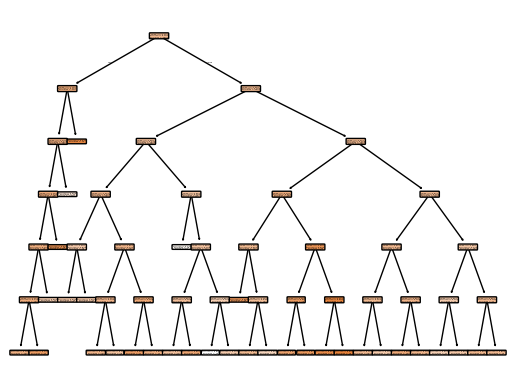

In [41]:
X = dataset.drop('salary_lpa', axis=1)
y = dataset['salary_lpa']

In [42]:
# we can also use this split  method 
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

In [50]:
dt_reg.fit(X,y)

,criterion,'poisson'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [43]:
feature_names = X.columns   # features names

print(feature_names)

Index(['cgpa', 'branch', 'college_tier', 'python_skill', 'dsa_skill',
       'ml_skill', 'web_dev_skill', 'coding_score', 'communication_score',
       'aptitude_score', 'internships', 'projects', 'backlogs', 'resume_score',
       'skill_score', 'placed', 'company_type', 'job_role'],
      dtype='object')


[Text(0.3004807692307692, 0.9285714285714286, 'cgpa <= 5.195\npoisson = 0.752\nsamples = 9000\nvalue = 2.499'),
 Text(0.11538461538461539, 0.7857142857142857, 'cgpa <= 5.185\npoisson = 0.757\nsamples = 310\nvalue = 2.697'),
 Text(0.2079326923076923, 0.8571428571428572, 'True  '),
 Text(0.09615384615384616, 0.6428571428571429, 'cgpa <= 5.175\npoisson = 0.773\nsamples = 296\nvalue = 2.669'),
 Text(0.07692307692307693, 0.5, 'cgpa <= 5.165\npoisson = 0.775\nsamples = 285\nvalue = 2.702'),
 Text(0.057692307692307696, 0.35714285714285715, 'cgpa <= 5.155\npoisson = 0.791\nsamples = 267\nvalue = 2.674'),
 Text(0.038461538461538464, 0.21428571428571427, 'cgpa <= 5.125\npoisson = 0.776\nsamples = 250\nvalue = 2.708'),
 Text(0.019230769230769232, 0.07142857142857142, 'poisson = 0.782\nsamples = 206\nvalue = 2.65'),
 Text(0.057692307692307696, 0.07142857142857142, 'poisson = 0.731\nsamples = 44\nvalue = 2.977'),
 Text(0.07692307692307693, 0.21428571428571427, 'poisson = 0.961\nsamples = 17\nvalue 

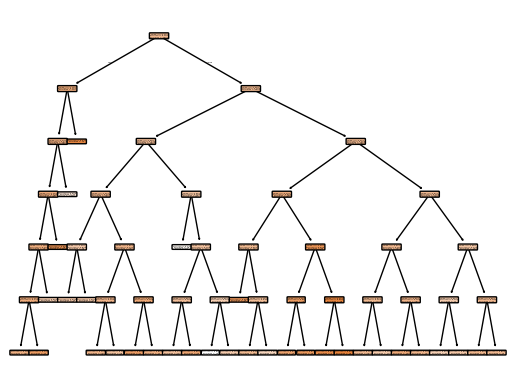

In [45]:
# Plot tree with class names (regression)

plot_tree(
    dt_reg,
    feature_names=X.columns,
    filled=True,
    rounded=True
)

In [47]:
# Features importance :

importance = dt_reg.feature_importances_

for name, score in zip(X.columns, importance):
    print(f"{name:25} : {score:.4f}")

cgpa                      : 1.0000


## Better Featrures importance Graph

In [49]:
print(X.shape)

print(len(X.columns))

print(len(dt_reg.feature_importances_))

print(dt_reg.feature_importances_)

(9000, 18)
18
1
[1.]


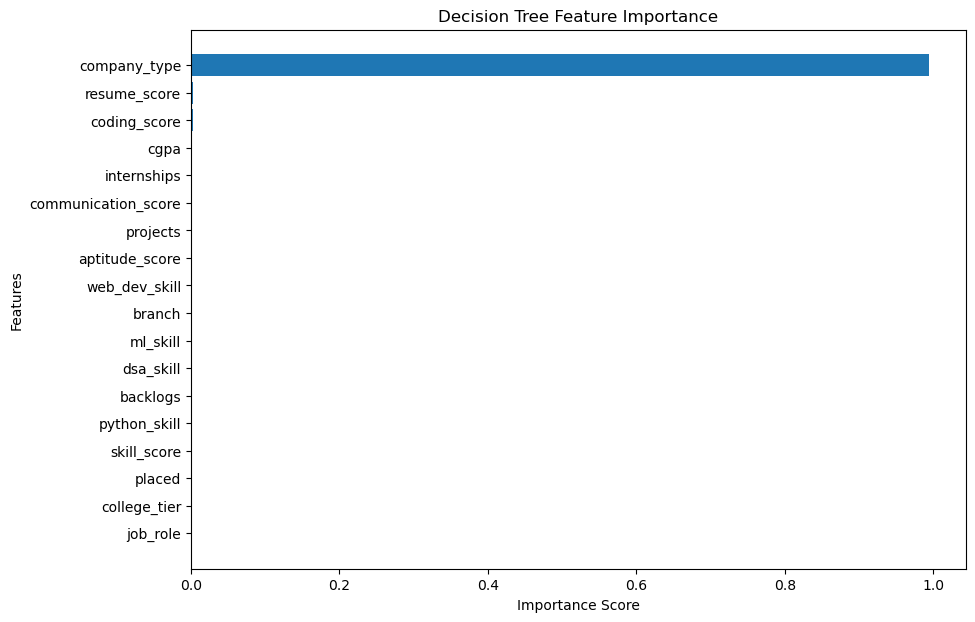

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_reg.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,7))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Decision Tree Feature Importance")

plt.gca().invert_yaxis()

plt.show()